In [48]:
from scipy.signal import find_peaks
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
import numpy as np
import os

RUN_DIR = "/Volumes/SherlockScratch/DSMC_FEM_VALIDATION_P1/BEAM_LOCKIN/PHASE_2"
RUNS = ["E_0.396MPa", "E_0.501MPa", "E_0.558MPa", "E_0.681MPa", "E_0.748MPa", "E_0.890MPa"]

RELATIVE_PEAK_HEIGHT = 0.1
RESTART_TIME_OFFSET = 100000 * 1e-6

TIP_COMPONENT = 'y'
TIP_LABEL = f"Tip disp. {TIP_COMPONENT} [m]"

def load_lift_drag(path):
    step, time, drag, lift = np.loadtxt(path, skiprows=1, unpack=True)
    return time, lift, drag

def load_tip_displacement(path, time_offset):
    """Parse an AERO-S gdisplac file: a 2-line header (title, node count),
    then repeating blocks of [1 time line] + [nnodes x "dx dy dz" lines].
    Returns (time, tip_x, tip_y, tip_z) using the LAST node in each block --
    the free end of the cantilever (node 1, the clamped root, is always the
    first node line and is always exactly zero)."""
    with open(path) as f:
        lines = f.readlines()

    nnodes = int(lines[1])
    block_size = 1 + nnodes
    body = lines[2:]
    n_blocks = len(body) // block_size

    times = np.empty(n_blocks)
    tip = np.empty((n_blocks, 3))
    for b in range(n_blocks):
        block = body[b * block_size:(b + 1) * block_size]
        times[b] = float(block[0])
        tip[b] = [float(v) for v in block[-1].split()]

    times = times + time_offset
    return times, tip[:, 0], tip[:, 1], tip[:, 2]

def load_natural_frequencies(path):
    """Parse an AERO-S eigen.out modal-analysis log: skip down to the
    "Mode  Omega^2  Frequency" table (2 header lines, then one dashed
    line) and read the Frequency column until the closing dashed line.
    Returns frequencies ordered by mode, so index 0 is the fundamental."""
    with open(path) as f:
        lines = f.readlines()

    header = next(i for i, line in enumerate(lines) if line.strip().startswith("Mode"))
    freqs = []
    for line in lines[header + 2:]:
        parts = line.split()
        if len(parts) != 3:
            break
        freqs.append(float(parts[2]))
    return np.array(freqs)

def fft_and_peaks(signal, dt, label, relative_height=RELATIVE_PEAK_HEIGHT):
    freq = np.fft.rfftfreq(len(signal), d=dt)
    mag = np.abs(np.fft.rfft(signal - signal.mean()))
    peak_idx, _ = find_peaks(mag, height=relative_height * mag.max(), distance=5)
    order = np.argsort(mag[peak_idx])[::-1]
    print(f"Detected Dominant Frequencies ({label}):")
    for f, a in zip(freq[peak_idx][order], mag[peak_idx][order]):
        print(f"-> Frequency: {f:.2f} Hz | Amplitude: {a:.2f}")
    return freq, mag, freq[peak_idx][order], mag[peak_idx][order]

def trim(time, signal, window):
    """Slice (time, signal) to the inclusive [t0, t1] window. Either bound
    may be None to mean "keep to the start/end of the series"."""
    t0, t1 = window
    t0 = time[0] if t0 is None else t0
    t1 = time[-1] if t1 is None else t1
    mask = (time >= t0) & (time <= t1)
    return time[mask], signal[mask]

def find_analysis_window(time, signal, search_window=(None, None), **find_peaks_kwargs):
    """Restrict (time, signal) to a coarse search_window that just needs to
    exclude the startup transient, then locate oscillation peaks inside it.
    The precise analysis window is [time of first peak, time of last peak],
    which crops to whole cycles instead of an eyeballed cut. Falls back to
    the full search_window if fewer than 2 peaks are found. Returns
    ((t0, t1), peak_times, peak_values, (search_t0, search_t1))."""
    t_search, s_search = trim(time, signal, search_window)
    kwargs = dict(prominence=0.1 * np.ptp(s_search))
    kwargs.update(find_peaks_kwargs)
    peak_idx, _ = find_peaks(s_search - s_search.mean(), **kwargs)
    search_bounds = (t_search[0], t_search[-1])
    if len(peak_idx) < 2:
        return search_bounds, t_search[peak_idx], s_search[peak_idx], search_bounds
    peak_times = t_search[peak_idx]
    peak_values = s_search[peak_idx]
    return (peak_times[0], peak_times[-1]), peak_times, peak_values, search_bounds

In [49]:
# -- Load raw data for every run -----------------------------------------
DATA = {}
NATURAL_FREQUENCIES = {}
for run in RUNS:
    LD_FILE = os.path.join(RUN_DIR, run, "EXAMPLE_BEAM", "lift_drag.dat")
    GDISPLAC_FILE = os.path.join(RUN_DIR, run, "results_beam", "gdisplac")
    EIGEN_FILE = os.path.join(RUN_DIR, run, "eigen.out")
    time_ld, lift, drag = load_lift_drag(LD_FILE)
    time_tip, tip_x, tip_y, tip_z = load_tip_displacement(
        GDISPLAC_FILE, RESTART_TIME_OFFSET)
    tip_options = {
        'x': tip_x,
        'y': tip_y,
        'z': tip_z,
        'magnitude': np.sqrt(tip_x**2 + tip_y**2 + tip_z**2),
    }
    DATA[run] = {
        'time_ld': time_ld,
        'lift': lift,
        'drag': drag,
        'time_tip': time_tip,
        'tip_disp': tip_options[TIP_COMPONENT],
    }
    NATURAL_FREQUENCIES[run] = load_natural_frequencies(EIGEN_FILE)

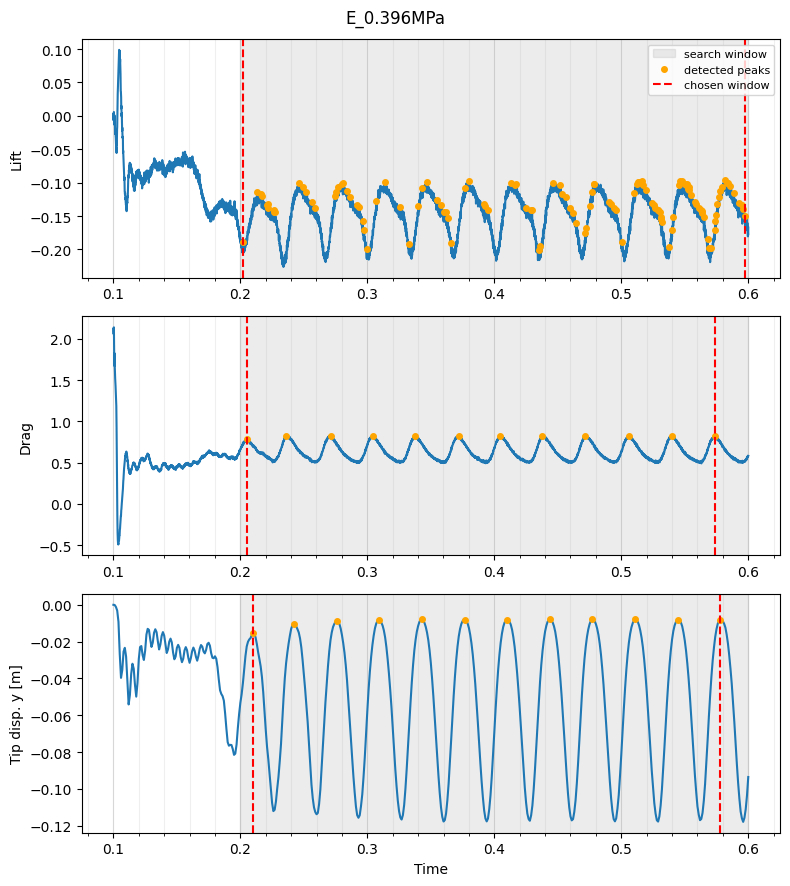

E_0.396MPa: lift (0.2019, 0.5977), drag (0.2054, 0.574), tip (0.21, 0.578)


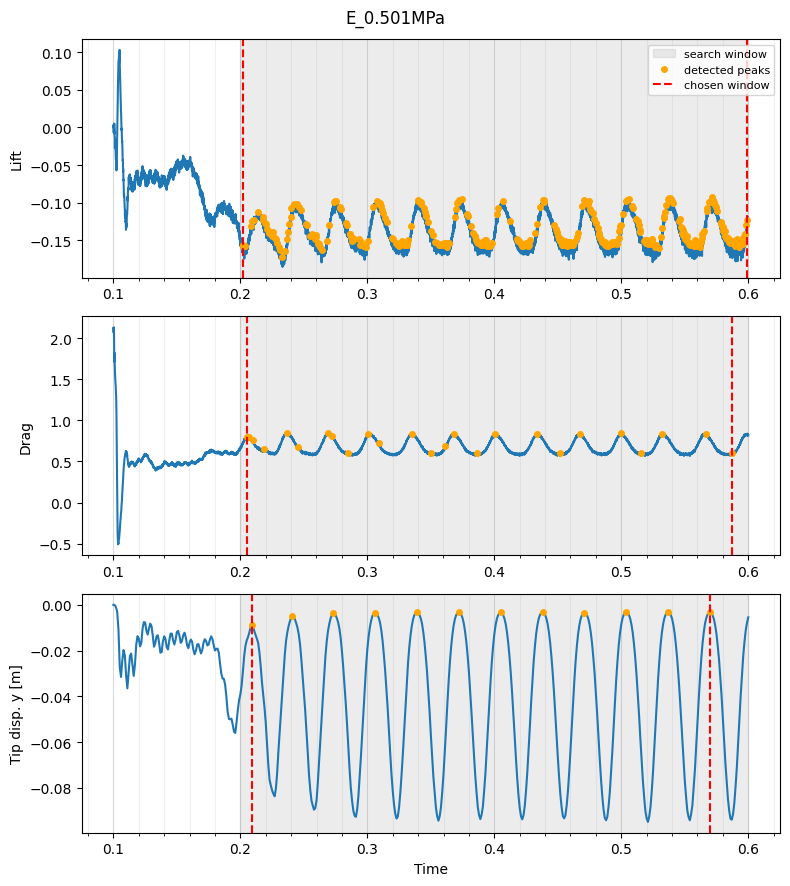

E_0.501MPa: lift (0.202, 0.5992), drag (0.2051, 0.5875), tip (0.209, 0.57)


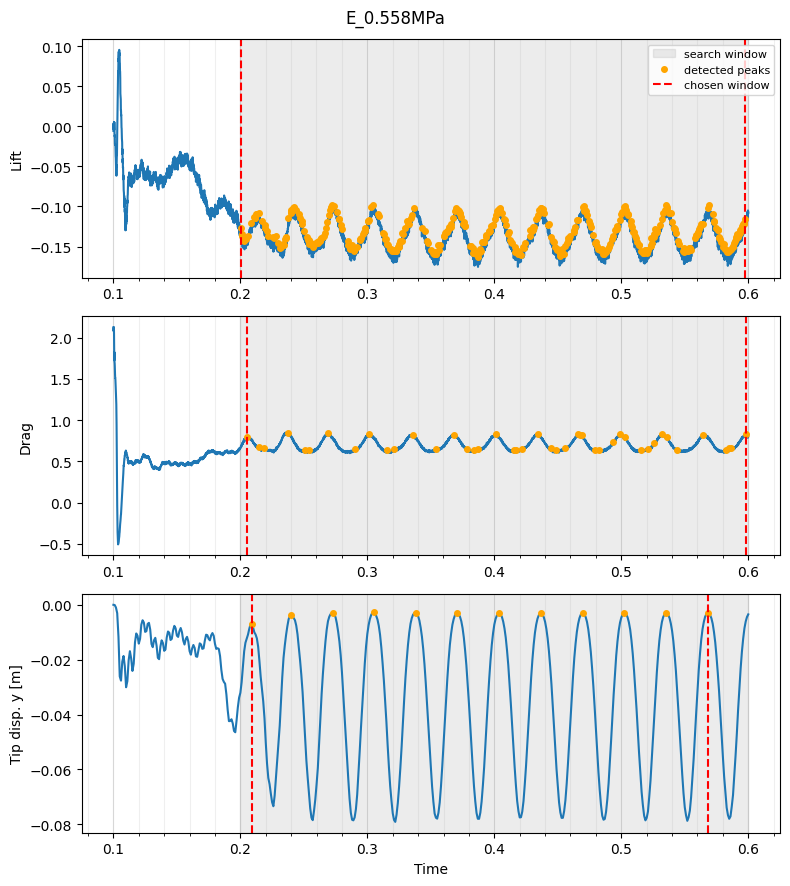

E_0.558MPa: lift (0.2004, 0.5974), drag (0.2056, 0.5984), tip (0.209, 0.5680000000000001)


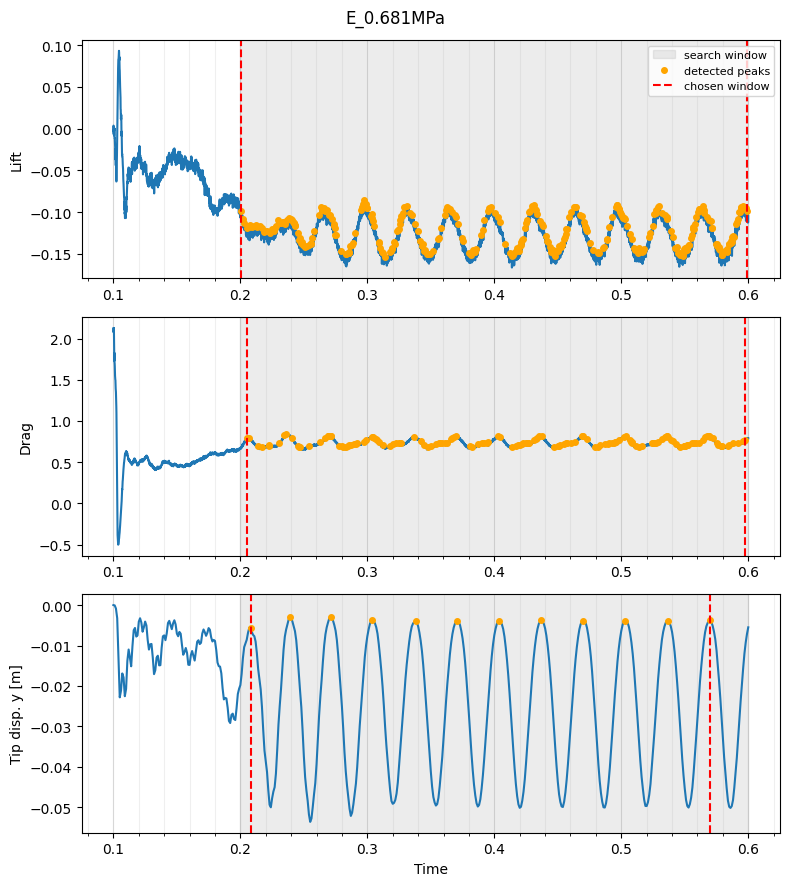

E_0.681MPa: lift (0.2003, 0.599), drag (0.2054, 0.5975), tip (0.208, 0.57)


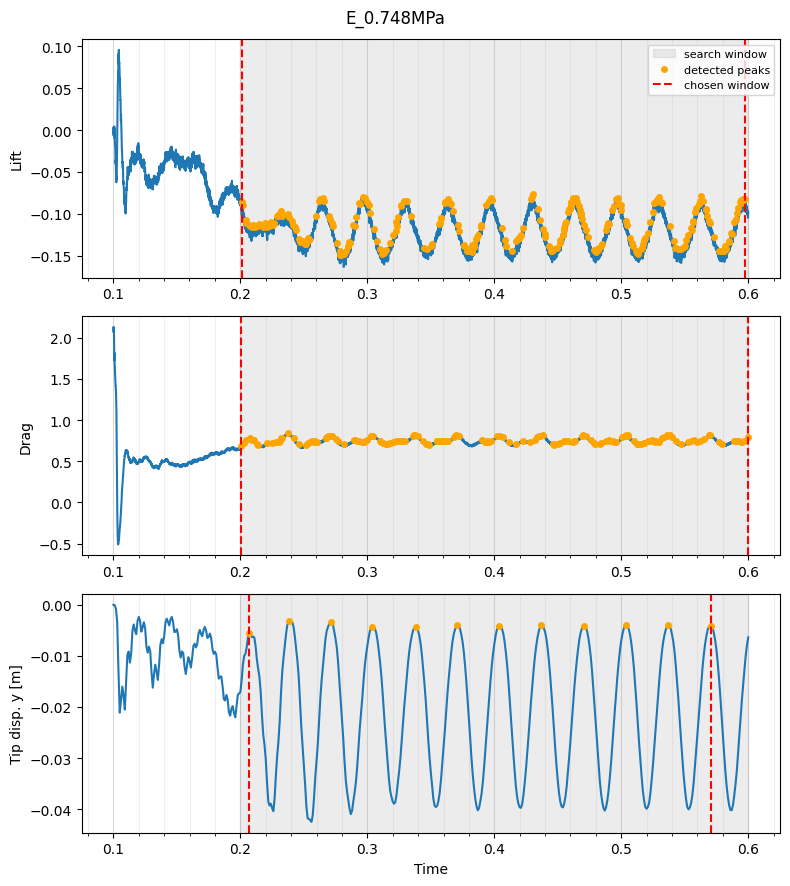

E_0.748MPa: lift (0.2013, 0.5978), drag (0.2007, 0.5995), tip (0.207, 0.571)


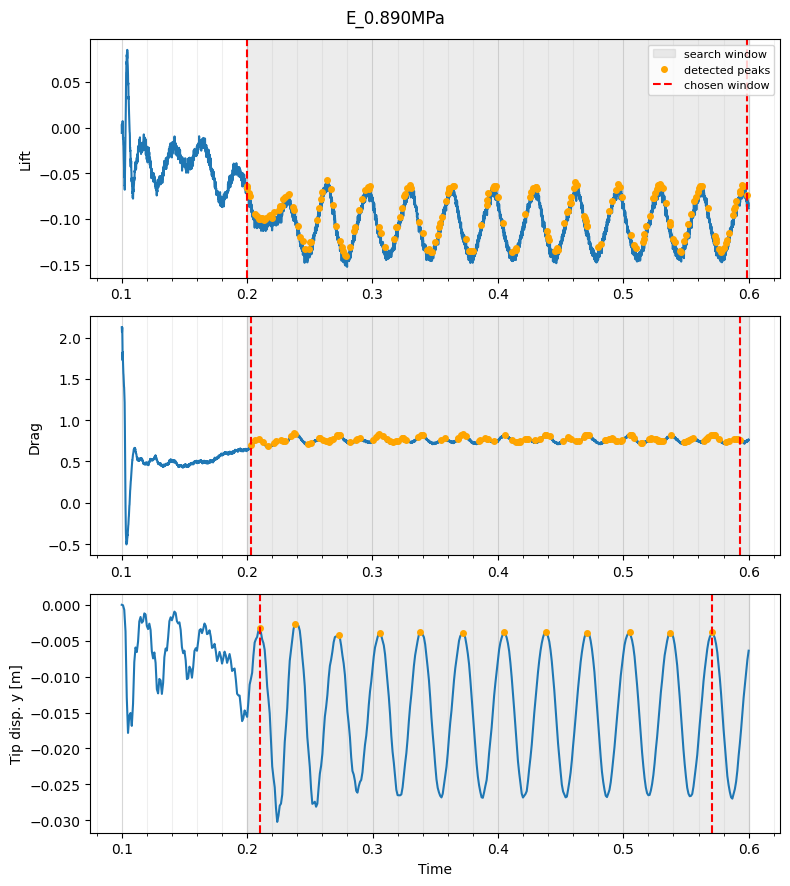

E_0.890MPa: lift (0.2001, 0.5989), drag (0.2032, 0.5929), tip (0.21, 0.571)


In [50]:
# -- Automatically pick the analysis window from detected peaks -------------
# For each run/signal, only set a coarse search window below if you need to
# keep the automatic peak search away from a startup transient or an
# end-of-run artifact -- it doesn't need to be precise. The exact analysis
# window is then [time of first peak, time of last peak] found inside it.
# Leave a bound as None to use the full extent of that signal's series.
SEARCH_WINDOWS = {
    run: {'lift': (0.2, None), 'drag': (0.2, None), 'tip': (0.2, None)}
    for run in RUNS
}

# Example — only needed where the plot below shows a bad window:
# SEARCH_WINDOWS["E_0.396MPa"]["tip"] = (0.02, None)

TRIM_WINDOWS = {}
for run, d in DATA.items():
    search = SEARCH_WINDOWS[run]
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, sharex=False, figsize=(8, 9))
    fig.suptitle(run)

    TRIM_WINDOWS[run] = {}
    for ax, time, signal, key, ylabel in (
        (ax1, d['time_ld'], d['lift'], 'lift', "Lift"),
        (ax2, d['time_ld'], d['drag'], 'drag', "Drag"),
        (ax3, d['time_tip'], d['tip_disp'], 'tip', TIP_LABEL),
    ):
        window, peak_times, peak_values, search_bounds = find_analysis_window(
            time, signal, search[key])
        TRIM_WINDOWS[run][key] = window

        ax.plot(time, signal)
        ax.axvspan(*search_bounds, color='gray', alpha=0.15, label='search window')
        ax.plot(peak_times, peak_values, 'o', color='orange', ms=4, label='detected peaks')
        ax.axvline(window[0], color='red', linestyle='--', label='chosen window')
        ax.axvline(window[1], color='red', linestyle='--')
        ax.set_ylabel(ylabel)
        ax.xaxis.set_minor_locator(AutoMinorLocator())
        ax.grid(True, which='major', axis='x', alpha=0.5)
        ax.grid(True, which='minor', axis='x', alpha=0.2)

    ax1.legend(loc='upper right', fontsize=8)
    ax3.set_xlabel("Time")
    plt.tight_layout()
    plt.show()

    print(f"{run}: lift {TRIM_WINDOWS[run]['lift']}, "
          f"drag {TRIM_WINDOWS[run]['drag']}, tip {TRIM_WINDOWS[run]['tip']}")

=== E_0.396MPa ===
Detected Dominant Frequencies (Lift):
-> Frequency: 30.31 Hz | Amplitude: 75.32
-> Frequency: 60.62 Hz | Amplitude: 24.66
-> Frequency: 88.41 Hz | Amplitude: 9.33
Detected Dominant Frequencies (Drag):
-> Frequency: 29.83 Hz | Amplitude: 258.64
-> Frequency: 59.67 Hz | Amplitude: 72.32
Detected Dominant Frequencies (Tip disp. (y)):
-> Frequency: 29.81 Hz | Amplitude: 9.90
-> Frequency: 59.62 Hz | Amplitude: 1.60


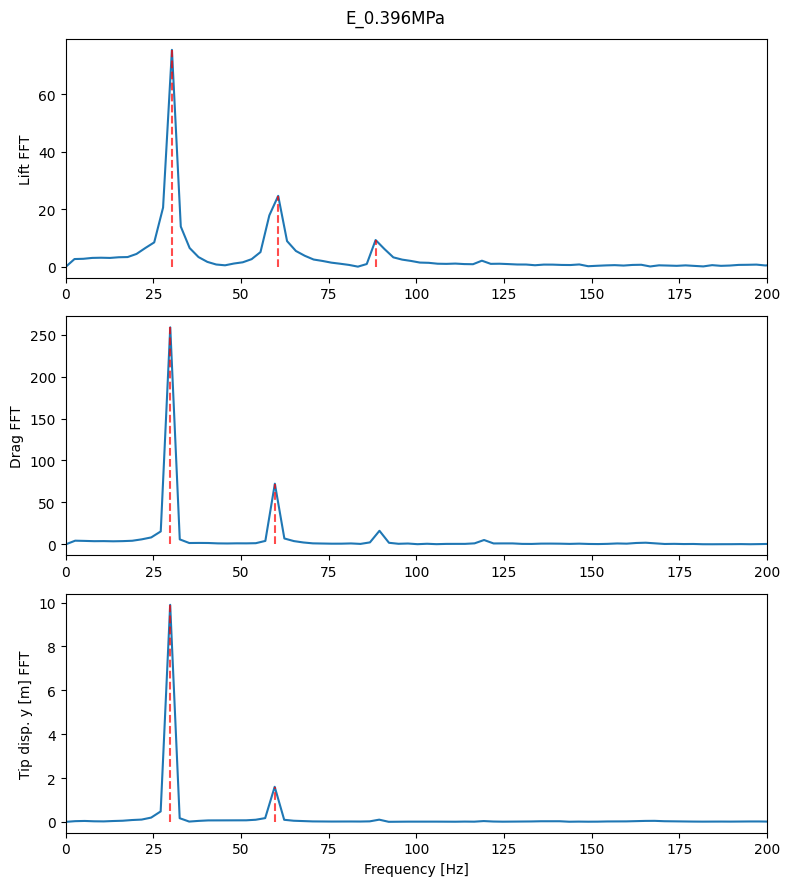

=== E_0.501MPa ===
Detected Dominant Frequencies (Lift):
-> Frequency: 30.20 Hz | Amplitude: 54.91
-> Frequency: 60.41 Hz | Amplitude: 13.99
-> Frequency: 90.61 Hz | Amplitude: 5.56
Detected Dominant Frequencies (Drag):
-> Frequency: 31.37 Hz | Amplitude: 180.17
-> Frequency: 60.13 Hz | Amplitude: 45.35
Detected Dominant Frequencies (Tip disp. (y)):
-> Frequency: 30.39 Hz | Amplitude: 8.01
-> Frequency: 60.77 Hz | Amplitude: 1.31


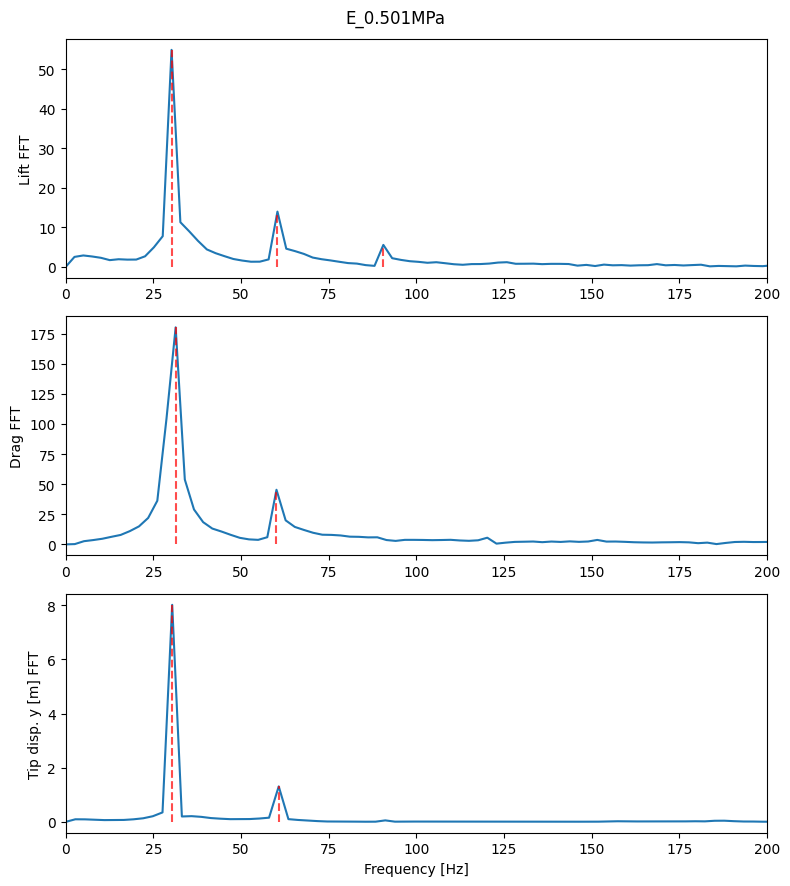

=== E_0.558MPa ===
Detected Dominant Frequencies (Lift):
-> Frequency: 30.22 Hz | Amplitude: 44.60
-> Frequency: 60.44 Hz | Amplitude: 6.05
Detected Dominant Frequencies (Drag):
-> Frequency: 30.54 Hz | Amplitude: 187.26
-> Frequency: 61.08 Hz | Amplitude: 45.71
Detected Dominant Frequencies (Tip disp. (y)):
-> Frequency: 30.56 Hz | Amplitude: 6.70
-> Frequency: 61.11 Hz | Amplitude: 0.98


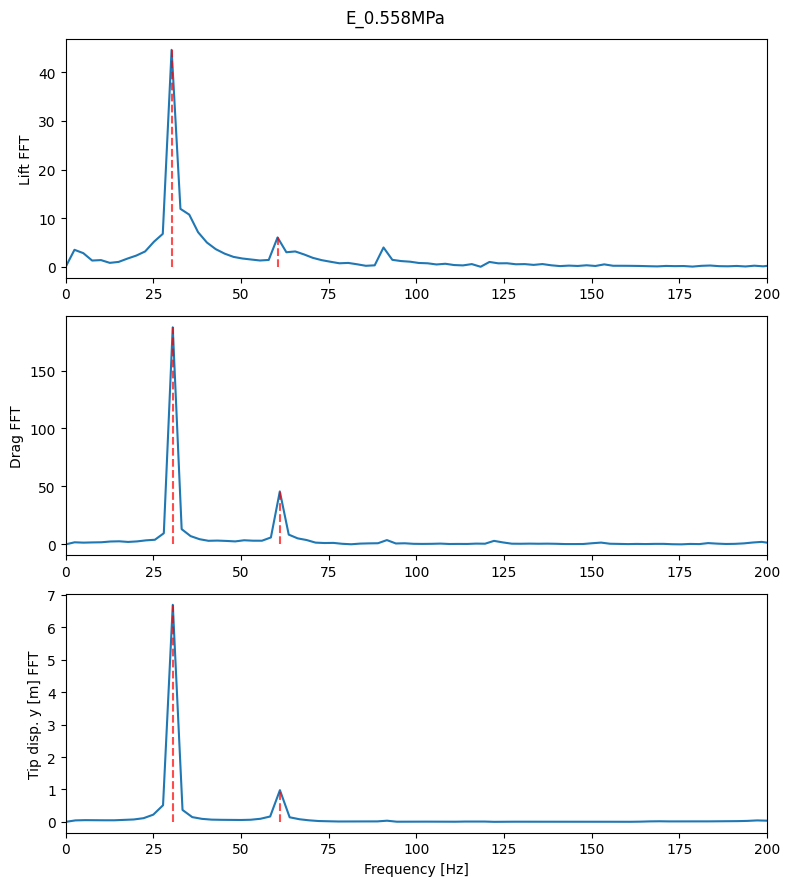

=== E_0.681MPa ===
Detected Dominant Frequencies (Lift):
-> Frequency: 30.09 Hz | Amplitude: 50.42
Detected Dominant Frequencies (Drag):
-> Frequency: 30.60 Hz | Amplitude: 98.94
-> Frequency: 61.19 Hz | Amplitude: 40.28
Detected Dominant Frequencies (Tip disp. (y)):
-> Frequency: 30.30 Hz | Amplitude: 4.21
-> Frequency: 60.61 Hz | Amplitude: 0.43


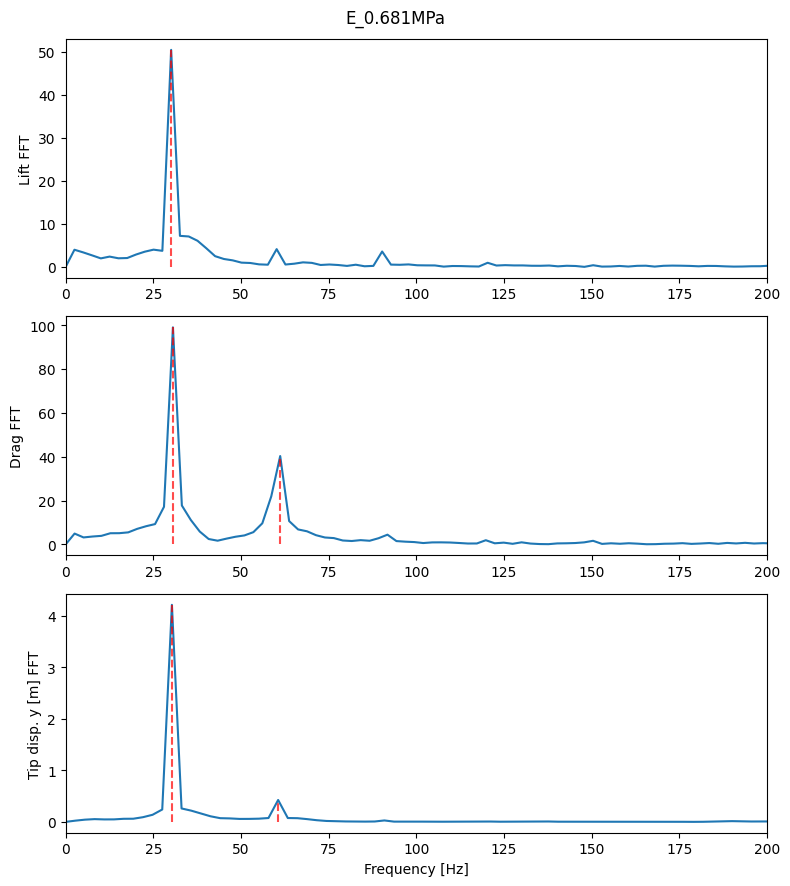

=== E_0.748MPa ===
Detected Dominant Frequencies (Lift):
-> Frequency: 30.26 Hz | Amplitude: 55.39
Detected Dominant Frequencies (Drag):
-> Frequency: 30.08 Hz | Amplitude: 76.36
-> Frequency: 60.17 Hz | Amplitude: 52.94
Detected Dominant Frequencies (Tip disp. (y)):
-> Frequency: 30.14 Hz | Amplitude: 3.30


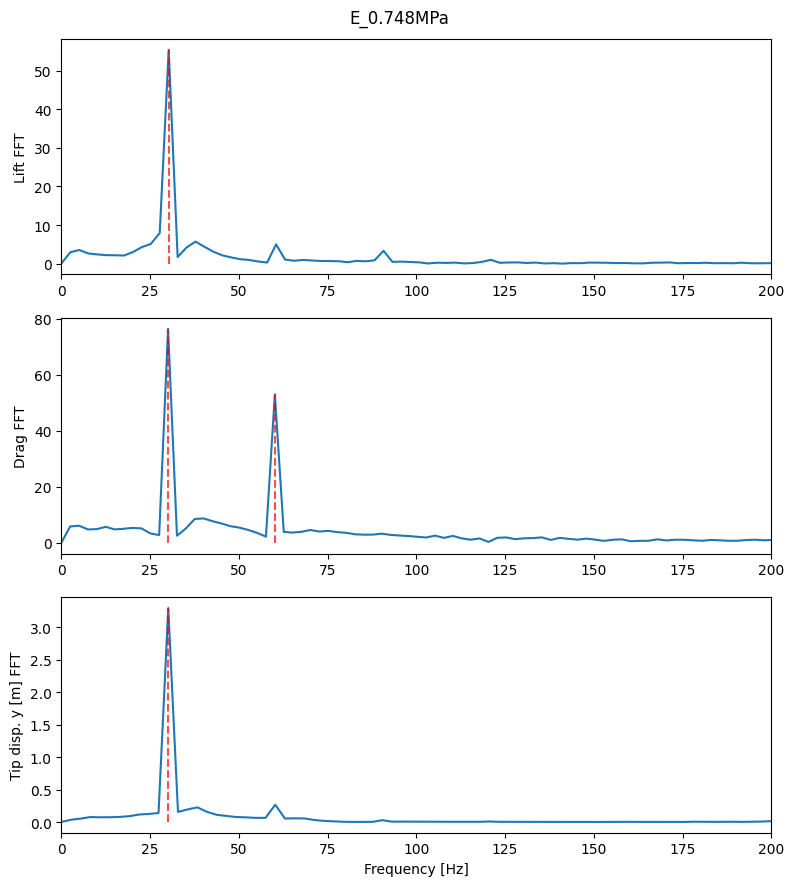

=== E_0.890MPa ===
Detected Dominant Frequencies (Lift):
-> Frequency: 30.08 Hz | Amplitude: 66.10
Detected Dominant Frequencies (Drag):
-> Frequency: 30.79 Hz | Amplitude: 40.79
-> Frequency: 61.57 Hz | Amplitude: 38.82
-> Frequency: 2.57 Hz | Amplitude: 8.13
-> Frequency: 92.36 Hz | Amplitude: 4.25
Detected Dominant Frequencies (Tip disp. (y)):
-> Frequency: 30.39 Hz | Amplitude: 2.08


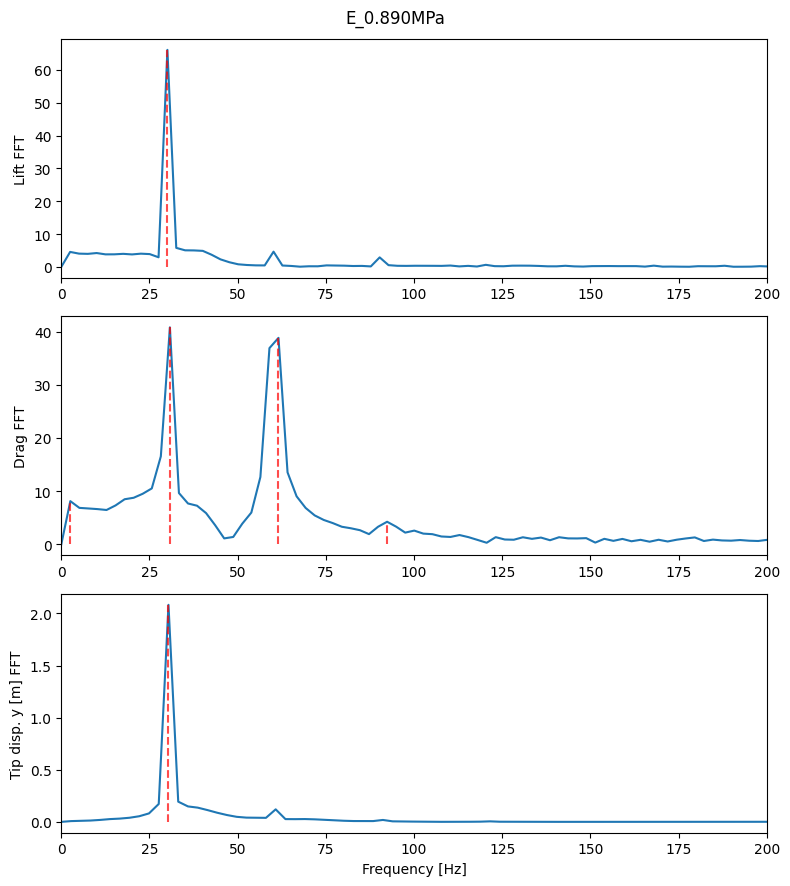

In [51]:
# -- FFT + dominant peak detection over the trimmed windows -----------------
# FFT_RESULTS[run][signal] holds all detected peaks (amplitude-sorted, so
# index 0 is the dominant frequency) for bookkeeping/cross-checking against
# NATURAL_FREQUENCIES[run] (mode 1 / index 0 is the beam's fundamental).
FFT_RESULTS = {}
for run, d in DATA.items():
    windows = TRIM_WINDOWS[run]
    time_lift, lift = trim(d['time_ld'], d['lift'], windows['lift'])
    time_drag, drag = trim(d['time_ld'], d['drag'], windows['drag'])
    time_tip, tip_disp = trim(d['time_tip'], d['tip_disp'], windows['tip'])

    dt_lift = time_lift[1] - time_lift[0]
    dt_drag = time_drag[1] - time_drag[0]
    dt_tip = time_tip[1] - time_tip[0]

    print(f"=== {run} ===")
    freq_lift, lift_fft, lift_pf, lift_pm = fft_and_peaks(lift, dt_lift, "Lift")
    freq_drag, drag_fft, drag_pf, drag_pm = fft_and_peaks(drag, dt_drag, "Drag")
    freq_tip, tip_fft, tip_pf, tip_pm = fft_and_peaks(tip_disp, dt_tip, f"Tip disp. ({TIP_COMPONENT})")

    FFT_RESULTS[run] = {
        'lift': {'frequencies': lift_pf, 'amplitudes': lift_pm},
        'drag': {'frequencies': drag_pf, 'amplitudes': drag_pm},
        'tip': {'frequencies': tip_pf, 'amplitudes': tip_pm},
    }

    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, sharex=False, figsize=(8, 9))
    fig.suptitle(run)

    for ax, freq, mag, pf, pm, ylabel in (
        (ax1, freq_lift, lift_fft, lift_pf, lift_pm, "Lift FFT"),
        (ax2, freq_drag, drag_fft, drag_pf, drag_pm, "Drag FFT"),
        (ax3, freq_tip, tip_fft, tip_pf, tip_pm, f"{TIP_LABEL} FFT"),
    ):
        ax.plot(freq, mag)
        ax.set_xlim(0, 200)
        ax.set_ylabel(ylabel)
        for f, a in zip(pf, pm):
            ax.vlines(f, 0, a, color='red', linestyle='--', alpha=0.7)
    ax3.set_xlabel("Frequency [Hz]")
    plt.tight_layout()
    plt.show()

In [52]:
# -- Summary: dominant simulated frequency vs. beam fundamental -------------
for run in RUNS:
    fundamental = NATURAL_FREQUENCIES[run][0]
    dom = {sig: FFT_RESULTS[run][sig]['frequencies'][0] for sig in ('lift', 'drag', 'tip')}
    print(f"{run}: fundamental={fundamental:.2f} Hz | "
          f"lift={dom['lift']:.2f} Hz, drag={dom['drag']:.2f} Hz, tip={dom['tip']:.2f} Hz")

E_0.396MPa: fundamental=26.69 Hz | lift=30.31 Hz, drag=29.83 Hz, tip=29.81 Hz
E_0.501MPa: fundamental=30.02 Hz | lift=30.20 Hz, drag=31.37 Hz, tip=30.39 Hz
E_0.558MPa: fundamental=31.69 Hz | lift=30.22 Hz, drag=30.54 Hz, tip=30.56 Hz
E_0.681MPa: fundamental=35.01 Hz | lift=30.09 Hz, drag=30.60 Hz, tip=30.30 Hz
E_0.748MPa: fundamental=36.69 Hz | lift=30.26 Hz, drag=30.08 Hz, tip=30.14 Hz
E_0.890MPa: fundamental=40.02 Hz | lift=30.08 Hz, drag=30.79 Hz, tip=30.39 Hz


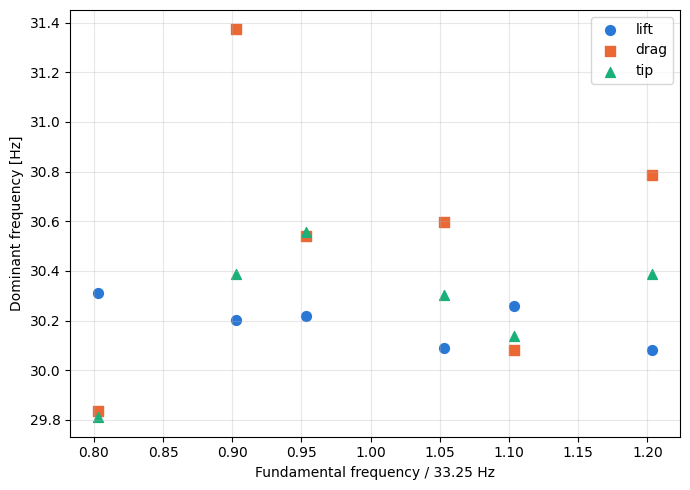

In [53]:
# -- Dominant frequencies vs. normalized beam fundamental --------------------
REFERENCE_FREQUENCY = 33.25  # Hz

SIGNAL_STYLE = {
    'lift': {'color': '#2a78d6', 'marker': 'o'},
    'drag': {'color': '#eb6834', 'marker': 's'},
    'tip': {'color': '#1baf7a', 'marker': '^'},
}

fig, ax = plt.subplots(figsize=(7, 5))
x = [NATURAL_FREQUENCIES[run][0] / REFERENCE_FREQUENCY for run in RUNS]
for signal, style in SIGNAL_STYLE.items():
    y = [FFT_RESULTS[run][signal]['frequencies'][0] for run in RUNS]
    ax.scatter(x, y, label=signal, s=50, **style)

ax.set_xlabel(f"Fundamental frequency / {REFERENCE_FREQUENCY} Hz")
ax.set_ylabel("Dominant frequency [Hz]")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

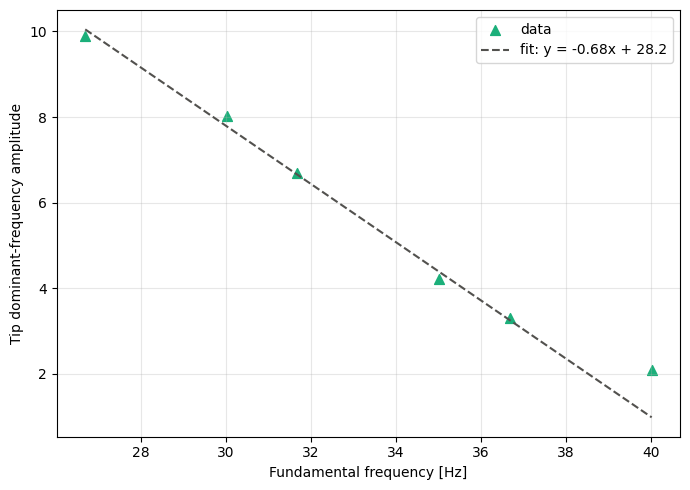

In [57]:
# -- Beam fundamental frequency vs. tip response amplitude ------------------
fig, ax = plt.subplots(figsize=(7, 5))
x = np.array([NATURAL_FREQUENCIES[run][0] for run in RUNS])
y = np.array([FFT_RESULTS[run]['tip']['amplitudes'][0] for run in RUNS])
ax.scatter(x, y, color='#1baf7a', marker='^', s=50, label='data')

slope, intercept = np.polyfit(x[:-1], y[:-1], 1)
x_fit = np.linspace(x.min(), x.max(), 100)
ax.plot(x_fit, slope * x_fit + intercept, color='#52514e', linestyle='--',
        label=f"fit: y = {slope:.3g}x + {intercept:.3g}")

ax.set_xlabel("Fundamental frequency [Hz]")
ax.set_ylabel("Tip dominant-frequency amplitude")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()